In [18]:
import pandas as pd
from pathlib import Path

# Resolve path relative to this script/notebook
PROJECT_ROOT = Path(__file__).parent.parent if '__file__' in locals() else Path('.').resolve().parent
csv_path = PROJECT_ROOT / 'data' / 'processed' / 'alonhadat_features_cleaned2.csv'

df = pd.read_csv(csv_path)


In [19]:
# Sort by price descending and look at the top 10
# Converting to Billions for easier reading
outliers = df[['title', 'locality', 'area_m2', 'price_vnd']].copy()
outliers['price_billion'] = outliers['price_vnd'] / 1_000_000_000
outliers = outliers.sort_values(by='price_billion', ascending=False)

print("Top 10 Most Expensive Listings:")
print(outliers.head(10))

Top 10 Most Expensive Listings:
                                                  title             locality  \
75    BÁN NHÀ MẶT TIỀN LỚN ĐƯỜNG NAM KỲ KHỞI NGHĨA -...      phường xuân hòa   
2741  MT 3A Lý Thường Kiệt, P.7, Tân Bình – Vị trí v...  phường tân sơn nhất   
205   🔥Siêu Vị Trí Ngay Chợ Bến Thành - MT Calmette ...     phường bến thành   
2351  Bán góc 3MT Nguyễn Văn Trỗi, P. 11, Q. PN - DT...     phường phú nhuận   
2136  Giảm sâu, bán gấp Tòa nhà Mặt tiền Bình Quới, ...     phường bình quới   
2258  Mặt Tiền Phan Đăng Lưu P1 PN- 10m*28m- 2Tầng -...      phường cầu kiệu   
2088  Cần bán tòa nhà MT Lê Thánh Tốn 4.4x21m hầm 8 ...       phường sài gòn   
751   Bán nhà góc 3MT Nguyễn Văn Trỗi PNDT: 13 x 24 ...     phường phú nhuận   
2281  Góc 2 MT ngay Lương Định Của, DT 405m2 - 12.5x...      phường an khánh   
2263  Siêu Phẩm Khan Hiếm Mặt Tiền Nam Kỳ Khởi Nghĩa...      phường xuân hòa   

      area_m2     price_vnd  price_billion  
75      150.0  1.170000e+11          117.0

In [28]:
print(df['metro_count_5km'].isnull().sum())

0


In [20]:
# Calculate price per square meter (in Millions VND)
df['price_per_m2_million'] = (df['price_vnd'] / df['area_m2']) / 1_000_000

# Sort to find unrealistic price/m2 ratios
ratio_outliers = df[['title', 'locality', 'area_m2', 'price_per_m2_million']].sort_values(by='price_per_m2_million', ascending=False)

print("\nTop 10 Highest Price/m2 Listings:")
print(ratio_outliers.head(10))


Top 10 Highest Price/m2 Listings:
                                                  title            locality  \
2513  Bán nhà HXH , khu vip Phú Thọ Hoà, Tân Phú, 51...  phường phú thọ hòa   
681   Bán Nhà MT Lê Anh Xuân P.Bến Thành Q1, DT 5x15...    phường bến thành   
2360  MT Đông Du đất vàng Bến Nghé Quận 1, DT 4mx13m...      phường sài gòn   
1     SIÊU VỊ TRÍ TÒA NHÀ HẦM 10 TẦNG LÊ THÁNH TÔN-Q...      phường sài gòn   
2060  SIÊU VỊ TRÍ TÒA NHÀ HẦM 10 TẦNG LÊ THÁNH TÔN, ...      phường sài gòn   
76    Siêu VIP Bến Thành, nhà 3 tầng, mặt tiền Ngô Đ...      phường sài gòn   
542   Hiếm! Mặt tiền Chu Mạnh Trinh, Bến Nghé, Quận ...      phường sài gòn   
68    💎 MẶT TIỀN SƯƠNG NGUYỆT ÁNH – QUẬN 1 – GIÁ TRỊ...    phường bến thành   
2088  Cần bán tòa nhà MT Lê Thánh Tốn 4.4x21m hầm 8 ...      phường sài gòn   
2036  BÁN NHÀ CHÍNH CHỦ MẶT TIỀN LÝ TỰ TRỌNG – TRUNG...      phường sài gòn   

      area_m2  price_per_m2_million  
2513     51.0           1388.235294  
681      75.0      

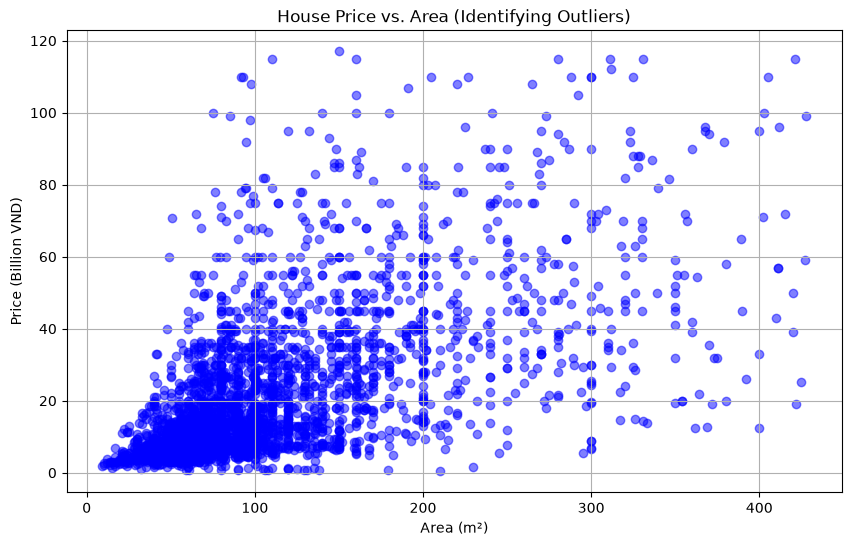

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['area_m2'], df['price_vnd'] / 1_000_000_000, alpha=0.5, color='blue')
plt.title('House Price vs. Area (Identifying Outliers)')
plt.xlabel('Area (m²)')
plt.ylabel('Price (Billion VND)')
plt.grid(True)
plt.show()

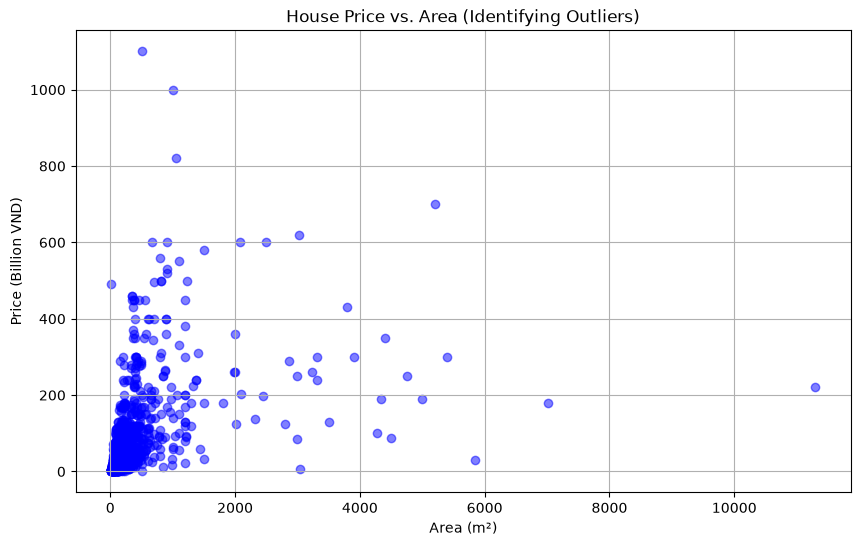

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['area_m2'], df['price_vnd'] / 1_000_000_000, alpha=0.5, color='blue')
plt.title('House Price vs. Area (Identifying Outliers)')
plt.xlabel('Area (m²)')
plt.ylabel('Price (Billion VND)')
plt.grid(True)
plt.show()